The objective of this project is to develop a binary classification model that predicts passenger survival on the Titanic using demographic and travel-related features. The model will be trained on labeled historical data and evaluated using classification accuracy.

In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [152]:
train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')

In [153]:
train_df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [154]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [155]:
train_df.shape

(891, 12)

In [156]:
print("Columns in train_df:", train_df.columns.tolist())


Columns in train_df: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [157]:
print("Number of survivors:", train_df[train_df['Survived'] == 1].shape[0])
print("Number of non-survivors:", train_df[train_df['Survived'] == 0].shape[0])

Number of survivors: 342
Number of non-survivors: 549


In [158]:
percentage_survived = (train_df[train_df['Survived'] == 1].shape[0] / train_df.shape[0]) * 100
print(f"Percentage of survivors: {percentage_survived:.2f}%")
percentage_non_survived = (train_df[train_df['Survived'] == 0].shape[0] / train_df.shape[0]) * 100
print(f"Percentage of non-survivors: {percentage_non_survived:.2f}%")

Percentage of survivors: 38.38%
Percentage of non-survivors: 61.62%


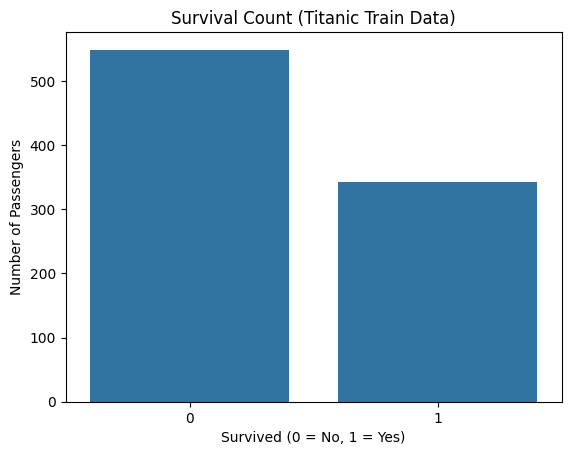

In [159]:

# Bar chart
plt.figure()
sns.countplot(x="Survived", data=train_df)

plt.title("Survival Count (Titanic Train Data)")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()

In [160]:
print("number of Females:", train_df[train_df['Sex'] == 'female'].shape[0])
print("number of Males:", train_df[train_df['Sex'] == 'male'].shape[0])

number of Females: 314
number of Males: 577


In [161]:
percentage_gender = (train_df[train_df['Sex'] == 'female'].shape[0] / train_df.shape[0]) * 100
print(f"Percentage of females: {percentage_gender:.2f}%")
percentage_male = (train_df[train_df['Sex'] == 'male'].shape[0] / train_df.shape[0]) * 100
print(f"Percentage of males: {percentage_male:.2f}%")


Percentage of females: 35.24%
Percentage of males: 64.76%


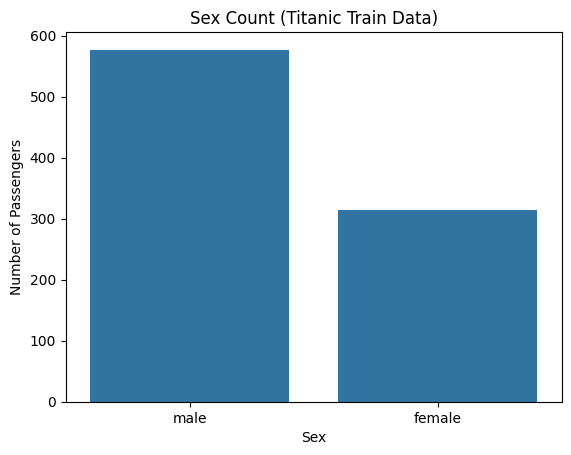

In [162]:

# Bar chart
plt.figure()
sns.countplot(x="Sex", data=train_df)

plt.title("Sex Count (Titanic Train Data)")
plt.xlabel("Sex")
plt.ylabel("Number of Passengers")

plt.show()

Total passengers by Gender:
Sex
male      577
female    314
Name: count, dtype: int64

Survival Rate by Gender (%):
Sex
female    74.20
male      18.89
Name: Survived, dtype: float64


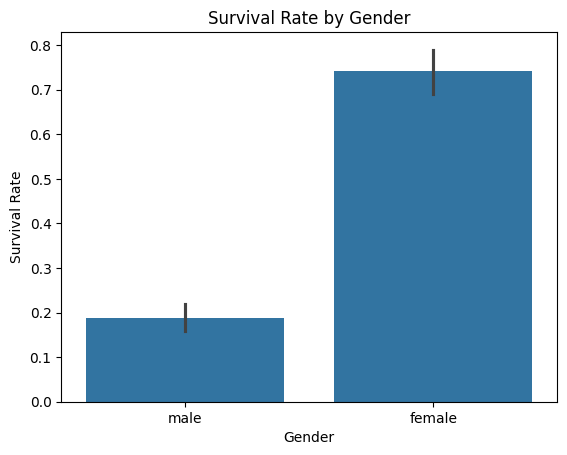

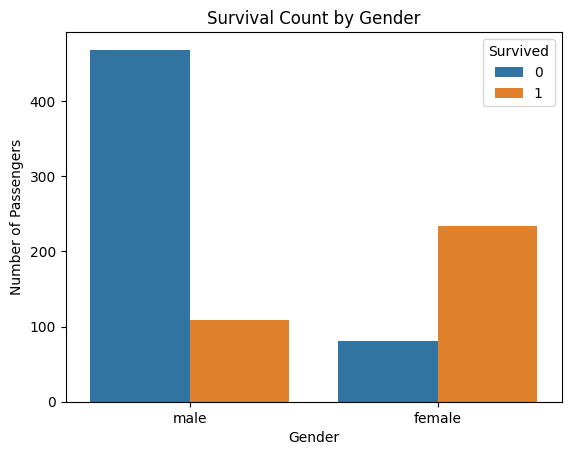

In [163]:
    

print("Total passengers by Gender:")
print(train_df["Sex"].value_counts())

survival_by_gender = train_df.groupby("Sex")["Survived"].mean() * 100

print("\nSurvival Rate by Gender (%):")
print(survival_by_gender.round(2))

plt.figure()
sns.barplot(x="Sex", y="Survived", data=train_df)

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")

plt.show()

plt.figure()
sns.countplot(x="Sex", hue="Survived", data=train_df)

plt.title("Survival Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()


Total passengers per Pclass:
Pclass
1    216
2    184
3    491
Name: count, dtype: int64

Survival Rate by Pclass (%):
Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64


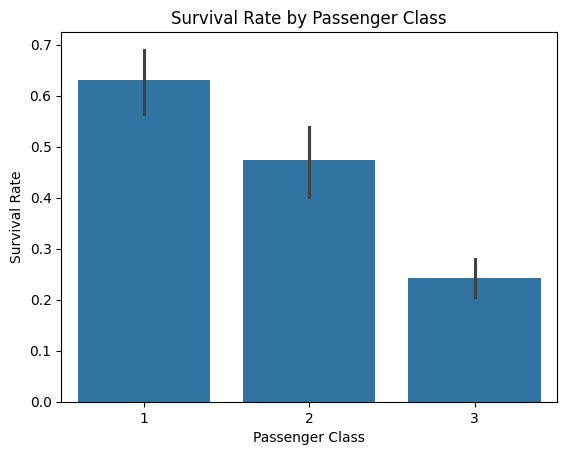

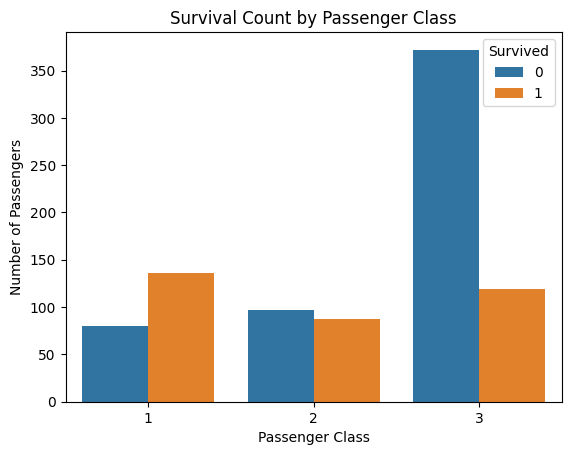

In [164]:

print("Total passengers per Pclass:")
print(train_df["Pclass"].value_counts().sort_index())

survival_by_class = train_df.groupby("Pclass")["Survived"].mean() * 100

print("\nSurvival Rate by Pclass (%):")
print(survival_by_class.round(2))

plt.figure()
sns.barplot(x="Pclass", y="Survived", data=train_df)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

plt.figure()
sns.countplot(x="Pclass", hue="Survived", data=train_df)

plt.title("Survival Count by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

In [165]:
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

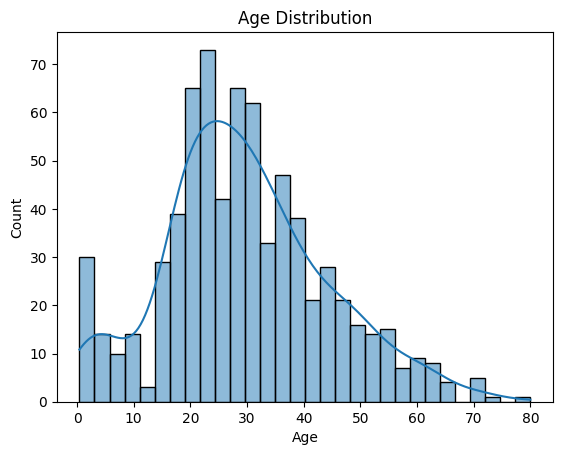

In [166]:
plt.figure()
sns.histplot(train_df["Age"], bins=30, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

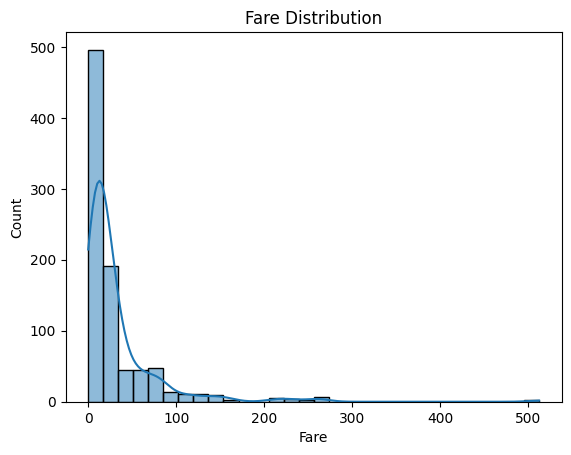

In [167]:
plt.figure()
sns.histplot(train_df["Fare"], bins=30, kde=True)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Count")

plt.show()

In [ ]:
# Compare Mean vs Median for Fare
fare_mean = train_df["Fare"].mean()
fare_median = train_df["Fare"].median()

print(f"Fare Mean: {fare_mean:.2f}")
print(f"Fare Median: {fare_median:.2f}")
print(f"Difference: {abs(fare_mean - fare_median):.2f}")

# Visualize both on histogram
plt.figure()
sns.histplot(train_df["Fare"], bins=30, kde=True)
plt.axvline(fare_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {fare_mean:.2f}')
plt.axvline(fare_median, color='green', linestyle='--', linewidth=2, label=f'Median: {fare_median:.2f}')
plt.title("Fare Distribution with Mean vs Median")
plt.xlabel("Fare")
plt.ylabel("Count")
plt.legend()
plt.show()